In [2]:
import pandas as pd ## dataframes
import numpy as np ## Mathematical operations
import matplotlib.pyplot as plt ## Representation
from matplotlib import rcParams
from matplotlib import colors
import random as random
import networkx as nx ## Network tools

In [3]:
def structural_characterization (filename):
    #read the file
    path = "activityA1/" + filename
    G_net = nx.read_pajek(path)
    G_net = nx.Graph(G_net)
    print(f'Structural characterization of '+ filename +' network:')

    #primary characteristics
    print('Number of nodes:', G_net.number_of_nodes())
    print('Number of edges:', G_net.number_of_edges())

    #degree
    degrees = [d for _, d in G_net.degree()]

    min_degree = min(degrees)
    max_degree = max(degrees)
    avg_degree = sum(degrees) / len(degrees)

    print(f"Minimum Degree: {min_degree}")
    print(f"Maximum Degree: {max_degree}")
    print(f"Average Degree: {avg_degree:.2f}")

    #clustering
    avg_clustering = nx.average_clustering(G_net)
    print(f"Average Clustering Coefficient: {avg_clustering:.4f}")

    r = nx.degree_assortativity_coefficient(G_net)
    print(f"Assortativity Coefficient (r): {r:.4f}")

    #paths characteristics
    if nx.is_connected(G_net):
        avg_path = nx.average_shortest_path_length(G_net)
        d = nx.diameter(G_net)
    else:
        largest_cc = max(nx.connected_components(G_net), key=len)
        G_lcc = G_net.subgraph(largest_cc)

        avg_path = nx.average_shortest_path_length(G_lcc)
        d = nx.diameter(G_lcc)

        print("Graph is not connected, using largest connected component")

    print(f"Average Shortest Path Length: {avg_path:.2f}")
    print(f"Diameter: {d}")

    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    return G_net

# Characterize their macroscopic structure net1, net2, net3 and net4

In [4]:
G_net1 = structural_characterization("net1.net")
G_net2 = structural_characterization("net2.net")
G_net3 = structural_characterization("net3.net")
G_net4 = structural_characterization("net4.net")

Structural characterization of net1.net network:
Number of nodes: 5000
Number of edges: 25000
Minimum Degree: 6
Maximum Degree: 16
Average Degree: 10.00
Average Clustering Coefficient: 0.4141
Assortativity Coefficient (r): -0.0097
Average Shortest Path Length: 5.12
Diameter: 8
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Structural characterization of net2.net network:
Number of nodes: 5000
Number of edges: 24873
Minimum Degree: 1
Maximum Degree: 24
Average Degree: 9.95
Average Clustering Coefficient: 0.0021
Assortativity Coefficient (r): -0.0057
Average Shortest Path Length: 3.96
Diameter: 7
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Structural characterization of net3.net network:
Number of nodes: 5000
Number of edges: 23508
Minimum Degree: 3
Maximum Degree: 732
Average Degree: 9.40
Average Clustering Coefficient: 0.0862
Assortativity Coefficient (r): -0.1339
Average Shortest Path Length: 3.01
Diameter: 5
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

In [5]:
from collections import Counter

def degree_distribution(G):
    fig, ax = plt.subplots(figsize=(5, 3))
    
    degree_sequence = [G.degree(node) for node in G.nodes()]
    num_nodes = len(G.nodes())
    
    degree_counts = Counter(degree_sequence)
    min_degree = min(degree_sequence)
    max_degree = max(degree_sequence)

    degrees = list(range(min_degree, max_degree + 1))
    degree_probs = [degree_counts.get(x, 0) / num_nodes for x in degrees]

    ax.scatter(degrees, degree_probs, label='data')

    ax.set_xlabel('$k$', fontsize=15)
    ax.set_ylabel('$P(k)$', fontsize=15)
    ax.tick_params(which='major', axis='both', labelsize=15)
    ax.set_title('Degree Distribution (Linear Scale)', fontsize=15)
    
    fig.tight_layout()
    plt.show()


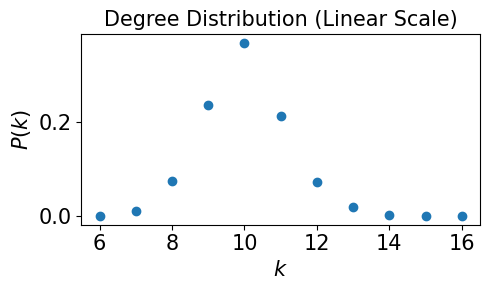

In [6]:
degree_distribution(G_net1)

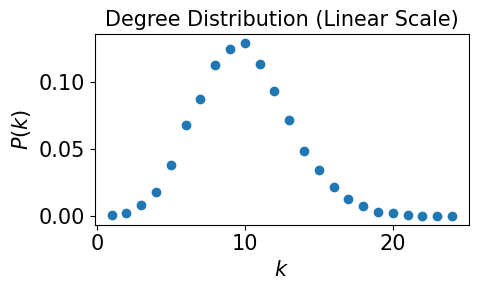

In [7]:
degree_distribution(G_net2)

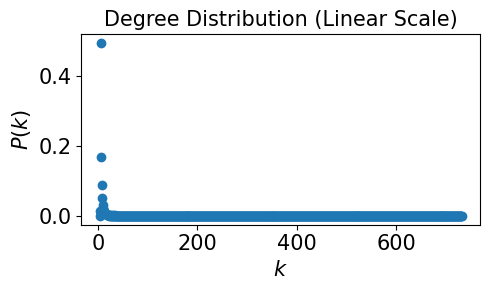

In [8]:
degree_distribution(G_net3)

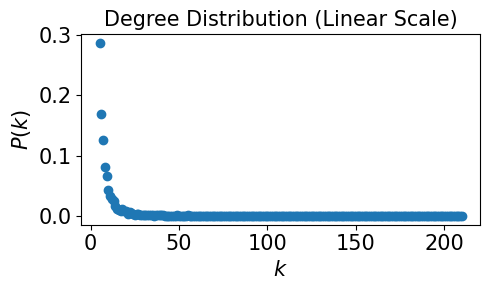

In [9]:
degree_distribution(G_net4)

In [7]:
def plot_log_binning(G, num_bins=10):
    degree_sequence = [G.degree(n) for n in G.nodes() if G.degree(n) > 0]
    num_nodes = len(G.nodes())
    
    min_deg, max_deg = min(degree_sequence), max(degree_sequence)
    bins = np.logspace(np.log10(min_deg), np.log10(max_deg), num_bins + 1)
    
    counts, bin_edges = np.histogram(degree_sequence, bins=bins)
    
    # Normalize
    bin_widths = np.diff(bin_edges)
    density = counts / (num_nodes * bin_widths)
    
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    idx = density > 0
    log_k = np.log10(bin_centers[idx])
    log_P = np.log10(density[idx])
    
    m, b = np.polyfit(log_k, log_P, 1)
    
    theoretical_P = 10**(m * np.log10(bin_centers) + b)
    
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.scatter(bin_centers, density)

    ax.plot(bin_centers, theoretical_P, 'k-', label=f'$\\gamma = {-m:.2f}$')
    
    # Set both axes to log scale
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    ax.set_xlabel('$k$', fontsize=15)
    ax.set_ylabel('$P(k)$', fontsize=15)
    ax.set_title('Degree Distribution (Log Binning)', fontsize=15)
    ax.legend()

    fig.tight_layout()
    plt.show()

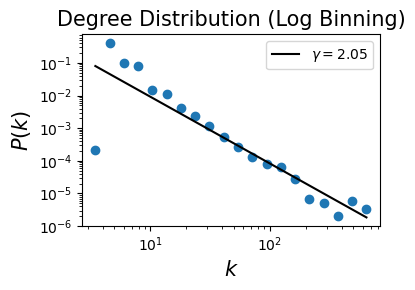

In [8]:
plot_log_binning(G_net3, num_bins=20)

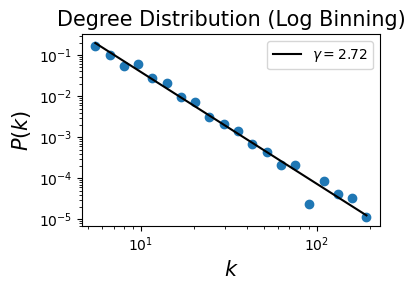

In [9]:
plot_log_binning(G_net4, num_bins=20)

In [10]:
def top5_centralities_calculation(G_net):
    eigenvector_centralities=nx.eigenvector_centrality(G_net)
    sorted_eigenvector = sorted(eigenvector_centralities, key=lambda node: eigenvector_centralities[node], reverse=True)
    for node in sorted_eigenvector[:5]:
        print(f"Node: {node}, Eigenvector Centrality: {eigenvector_centralities[node]:.4f}")
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

    betweenness_centralities=nx.betweenness_centrality(G_net)
    sorted_betweenness = sorted(betweenness_centralities, key=lambda node: betweenness_centralities[node], reverse=True)
    for node in sorted_betweenness[:5]:
        print(f"Node: {node}, Betweenness Centrality: {betweenness_centralities[node]:.4f}")
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

    degree_centralities_values=nx.degree_centrality(G_net)
    sorted_degree = sorted(degree_centralities_values, key=lambda node: degree_centralities_values[node], reverse=True)
    for node in sorted_degree[:5]:
        print(f"Node: {node}, Degree Centrality: {degree_centralities_values[node]:.4f}")

In [11]:
top5_centralities_calculation(G_net1)

Node: 651, Eigenvector Centrality: 0.0286
Node: 1937, Eigenvector Centrality: 0.0265
Node: 4526, Eigenvector Centrality: 0.0256
Node: 4398, Eigenvector Centrality: 0.0253
Node: 1939, Eigenvector Centrality: 0.0252
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Node: 4747, Betweenness Centrality: 0.0041
Node: 2645, Betweenness Centrality: 0.0040
Node: 230, Betweenness Centrality: 0.0038
Node: 4360, Betweenness Centrality: 0.0038
Node: 1579, Betweenness Centrality: 0.0037
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Node: 1693, Degree Centrality: 0.0032
Node: 651, Degree Centrality: 0.0030
Node: 1579, Degree Centrality: 0.0030
Node: 4891, Degree Centrality: 0.0030
Node: 41, Degree Centrality: 0.0028


In [12]:
top5_centralities_calculation(G_net2)

Node: 1581, Eigenvector Centrality: 0.0412
Node: 3233, Eigenvector Centrality: 0.0343
Node: 787, Eigenvector Centrality: 0.0341
Node: 2375, Eigenvector Centrality: 0.0337
Node: 131, Eigenvector Centrality: 0.0335
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Node: 1581, Betweenness Centrality: 0.0033
Node: 787, Betweenness Centrality: 0.0026
Node: 4382, Betweenness Centrality: 0.0025
Node: 52, Betweenness Centrality: 0.0023
Node: 2375, Betweenness Centrality: 0.0023
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Node: 1581, Degree Centrality: 0.0048
Node: 787, Degree Centrality: 0.0046
Node: 52, Degree Centrality: 0.0042
Node: 1990, Degree Centrality: 0.0042
Node: 2372, Degree Centrality: 0.0042


In [13]:
top5_centralities_calculation(G_net3)

Node: 5, Eigenvector Centrality: 0.2592
Node: 7, Eigenvector Centrality: 0.2417
Node: 2, Eigenvector Centrality: 0.2254
Node: 0, Eigenvector Centrality: 0.2254
Node: 3, Eigenvector Centrality: 0.2070
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Node: 5, Betweenness Centrality: 0.1378
Node: 7, Betweenness Centrality: 0.1277
Node: 0, Betweenness Centrality: 0.1113
Node: 2, Betweenness Centrality: 0.1093
Node: 6, Betweenness Centrality: 0.0943
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Node: 5, Degree Centrality: 0.1464
Node: 7, Degree Centrality: 0.1382
Node: 2, Degree Centrality: 0.1252
Node: 0, Degree Centrality: 0.1240
Node: 6, Degree Centrality: 0.1110


In [14]:
top5_centralities_calculation(G_net4)

Node: 6, Eigenvector Centrality: 0.2239
Node: 0, Eigenvector Centrality: 0.2234
Node: 9, Eigenvector Centrality: 0.2062
Node: 8, Eigenvector Centrality: 0.1741
Node: 3, Eigenvector Centrality: 0.1686
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Node: 0, Betweenness Centrality: 0.0605
Node: 6, Betweenness Centrality: 0.0576
Node: 9, Betweenness Centrality: 0.0553
Node: 8, Betweenness Centrality: 0.0391
Node: 3, Betweenness Centrality: 0.0379
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Node: 6, Degree Centrality: 0.0420
Node: 0, Degree Centrality: 0.0412
Node: 9, Degree Centrality: 0.0408
Node: 10, Degree Centrality: 0.0326
Node: 8, Degree Centrality: 0.0324


In [15]:
G_net5 = structural_characterization("net5.net")

Structural characterization of net5.net network:
Number of nodes: 200
Number of edges: 465
Minimum Degree: 1
Maximum Degree: 10
Average Degree: 4.65
Average Clustering Coefficient: 0.6107
Assortativity Coefficient (r): 0.5502
Graph is not connected, using largest connected component
Average Shortest Path Length: 13.13
Diameter: 35
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [16]:
def load_positions(filename):
    pos = {}
    
    with open(filename, 'r') as f:
        next(f)
        for line in f:
            node, x, y = line.split()
            pos[node] = (float(x), float(y))   # <-- no int()
    
    return pos

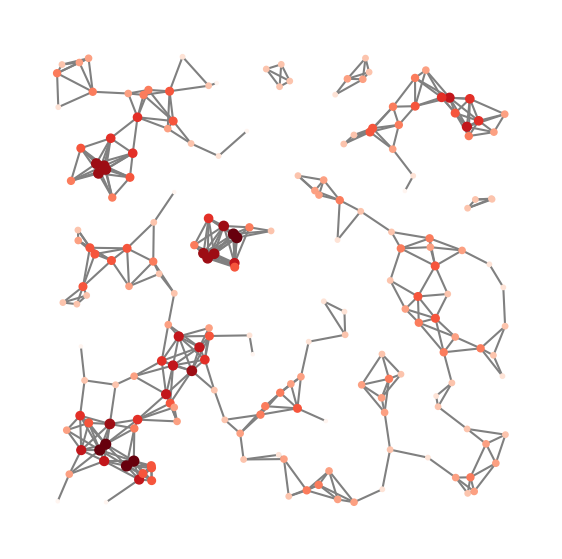

In [17]:
pos = load_positions("activityA1/positions_net5.txt")

color_nodes=[G_net5.degree(node) for node in G_net5.nodes()]

sizes_nodes=[5*G_net5.degree(node) for node in G_net5.nodes()]
positions=pos
fig=plt.figure(figsize=(7,7))
nx.draw_networkx(G_net5,node_size=sizes_nodes,pos=positions,edge_color='grey',node_color=color_nodes,width=1.5,with_labels=False,font_size=20,cmap='Reds')
## We recommend using a neutral color for the edges
plt.box(False)

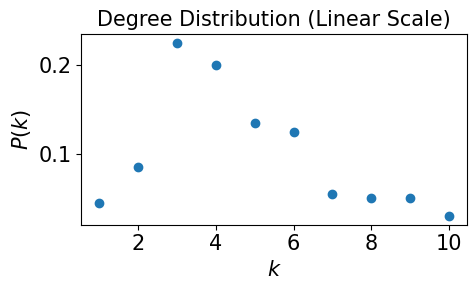

In [18]:
degree_distribution(G_net5)